# 10 — Precision Ponderada por Distancia Topológica

## Motivación

La métrica **Precision clásica** trata todos los Falsos Positivos (FP) con el mismo peso:

$$\text{Precision} = \frac{TP}{TP + FP}$$

donde $FP = \sum_{\text{nodos marcados}} \mathbf{1}[\text{nodo} \notin \text{nodos reales dañados}]$.

**Limitación:** un nodo FP a 1 miembro de distancia del elemento dañado castiga igual que uno
al otro extremo de la plataforma. Esto es ingenierieramente incorrecto para sistemas de monitoreo
estructural donde una detección cercana es cualitativamente mejor que una lejana.

## Solución: Precision Ponderada

Se define una **distancia topológica** $d(n_{FP},\ e_{dañado})$ como el número mínimo de
miembros estructurales (aristas del grafo) que separan el nodo FP de los nodos extremos
del elemento real dañado. Luego se penaliza cada FP proporcionalmente a su lejanía:

$$w(d) = \frac{d}{d+1} \qquad w \in [0, 1)$$

- $d=1$ (nodo adyacente): $w = 0.5$ → penalización reducida al 50%  
- $d=2$: $w = 0.67$  
- $d \to \infty$: $w \to 1.0$ → penalización completa

La **Precision ponderada** resulta:

$$\text{Precision}_w = \frac{TP}{TP + \sum_{i \in FP} w(d_i)}$$

Esta función preserva la interpretabilidad y no requiere hiperparámetros adicionales.

## Pipeline
1. Construir grafo topológico desde conectividad ETABS (Beam + Brace + Column)
2. Pre-computar distancias BFS desde todos los nodos
3. Extraer nodos FP por corrida desde `DetalleTodasCorridas.xlsx`
4. Calcular $\text{Precision}_w$ por corrida
5. Agregar por severidad × tipo de elemento
6. Comparar Precision clásica vs Precision ponderada
7. Exportar figuras y tabla LaTeX

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict, deque
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
%matplotlib inline

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 1. Rutas

In [5]:
base_path         = Path.home() / 'github' / 'Proyecto-doctoral'
resultados_nuevos = base_path / 'outputs' / 'resultados_nuevos'
tablas_dir        = base_path / 'manuscript_AOR' / 'tablas'
tablas_dir.mkdir(parents=True, exist_ok=True)

ETABS_XLSX = (
    base_path
    / 'pruebas_excel' / 'ETABS_modelo' / 'ETABS'
    / 'revision_6_jacket-subestructura_4NIVELES'
    / 'datos_revision_5_jacket-subestructura_5NIVELES.xlsx'
)

FUENTES = {
    'Denting': {
        'xlsx_res':    resultados_nuevos / 'abolladuras_2026' / 'todos_los_resultados_con_ICD_abolladura.xlsx',
        'xlsx_detail': base_path / 'Resultados' / 'abolladura_2026-02-26_05-26-02' / 'DetalleTodasCorridas.xlsx',
        'out_dir':     resultados_nuevos / 'abolladuras_2026',
        'cache':       resultados_nuevos / 'abolladuras_2026' / 'fp_nodes_cache_abolladura.pkl',
        'color':       '#E74C3C',
    },
    'Corrosion': {
        'xlsx_res':    resultados_nuevos / 'corrosion_2026' / 'todos_los_resultados_con_ICD_corrosion.xlsx',
        'xlsx_detail': base_path / 'Resultados' / 'corrosion_2026-02-27_06-07-17' / 'DetalleTodasCorridas.xlsx',
        'out_dir':     resultados_nuevos / 'corrosion_2026',
        'cache':       resultados_nuevos / 'corrosion_2026' / 'fp_nodes_cache_corrosion.pkl',
        'color':       '#2980B9',
    },
}

ELEM_COLORS  = {'Brace': '#E74C3C', 'Inclined_leg': '#2980B9', 'Beam': '#27AE60'}
ELEM_MARKERS = {'Brace': 'o', 'Inclined_leg': 's', 'Beam': '^'}
ELEM_LABELS  = {'Brace': 'Brace', 'Inclined_leg': 'Inclined Leg', 'Beam': 'Beam'}

for name, cfg in FUENTES.items():
    ok_res    = '✓' if cfg['xlsx_res'].exists()    else '✗'
    ok_detail = '✓' if cfg['xlsx_detail'].exists() else '✗'
    print(f'{name}: resultados {ok_res}  |  DetalleTodasCorridas {ok_detail}')
print(f'\nETABS: {"✓" if ETABS_XLSX.exists() else "✗"} {ETABS_XLSX.name}')

Denting: resultados ✓  |  DetalleTodasCorridas ✓
Corrosion: resultados ✓  |  DetalleTodasCorridas ✓

ETABS: ✓ datos_revision_5_jacket-subestructura_5NIVELES.xlsx


## 2. Construir Grafo Topológico desde ETABS

El grafo usa los nodos estructurales como vértices y cada miembro (Beam, Brace, Column)
como arista. Las distancias BFS dan el número de miembros entre dos nodos cualquiera.

In [6]:
def build_graph_from_etabs(etabs_path):
    """
    Lee las hojas de conectividad del Excel ETABS y construye:
    - adj: dict {nodo: set(vecinos)}  — grafo de adyacencia
    - elem_nodes: dict {etabs_unique_id: (nodo_i, nodo_j)}
    """
    xl = pd.ExcelFile(etabs_path)
    adj = defaultdict(set)
    elem_nodes = {}

    sheets = [
        ('Beam Object Connectivity',   'BeamBay'),
        ('Brace Object Connectivity',  'BraceBay'),
        ('Column Object Connectivity', 'ColumnBay'),
    ]
    n_edges = 0
    for sheet, bay_col in sheets:
        df = xl.parse(sheet, skiprows=2)
        df.columns = ['UniqueName', 'Story', bay_col, 'UniquePtI', 'UniquePtJ', 'Length', 'GUID']
        for _, row in df.iterrows():
            ni  = int(row['UniquePtI'])
            nj  = int(row['UniquePtJ'])
            eid = int(row['UniqueName'])
            adj[ni].add(nj)
            adj[nj].add(ni)
            elem_nodes[eid] = (ni, nj)
            n_edges += 1
        print(f'  {sheet}: {len(df)} elementos cargados')

    all_nodes = sorted(adj.keys())
    print(f'\nGrafo: {len(all_nodes)} nodos, {n_edges} aristas (miembros)')
    return dict(adj), elem_nodes, all_nodes


adj, elem_nodes_etabs, all_nodes = build_graph_from_etabs(ETABS_XLSX)
print('Ejemplo elem_nodes_etabs (primeros 5):', list(elem_nodes_etabs.items())[:5])

  Beam Object Connectivity: 28 elementos cargados
  Brace Object Connectivity: 100 elementos cargados
  Column Object Connectivity: 8 elementos cargados

Grafo: 52 nodos, 136 aristas (miembros)
Ejemplo elem_nodes_etabs (primeros 5): [(133, (52, 51)), (136, (50, 51)), (135, (49, 50)), (134, (49, 52)), (125, (48, 47))]


## 3. Pre-computar Distancias BFS (todos los nodos)

BFS desde cada nodo del grafo → matriz de distancias topológicas.  
Con 52 nodos y ~136 aristas, es instantáneo.

In [7]:
def bfs_distances(adj, start):
    """BFS desde 'start'. Retorna {nodo: distancia_en_aristas}."""
    dist = {start: 0}
    queue = deque([start])
    while queue:
        u = queue.popleft()
        for v in adj.get(u, []):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist


# Pre-computar para todos los nodos
all_distances = {}
for node in all_nodes:
    all_distances[node] = bfs_distances(adj, node)

print(f'Distancias pre-computadas para {len(all_distances)} nodos')

# Verificación: distancia entre nodo 1 (base) y nodo 52 (tope)
d_1_52 = all_distances.get(1, {}).get(52, '?')
print(f'Distancia nodo 1 → nodo 52: {d_1_52} miembros')

# Distribución de distancias máximas (diámetro del grafo)
max_dists = [max(v.values()) for v in all_distances.values()]
print(f'Diámetro del grafo (max dist entre dos nodos): {max(max_dists)} miembros')
print(f'Distancia media entre nodos: {np.mean([d for dct in all_distances.values() for d in dct.values()]):.2f}')

Distancias pre-computadas para 52 nodos
Distancia nodo 1 → nodo 52: 8 miembros
Diámetro del grafo (max dist entre dos nodos): 9 miembros
Distancia media entre nodos: 3.42


## 4. Cargar Resultados y Construir Lookup Elemento → Nodos

El `Elemento` en el Excel de resultados corresponde al `element_id` del catálogo,  
que a su vez coincide con el `UniqueName` del ETABS para los elementos del modelo.

In [8]:
dfs_res = {}

for damage_type, cfg in FUENTES.items():
    df = pd.read_excel(cfg['xlsx_res'])
    df['member_type'] = df['Tipo_elemento_a_buscar'].str.strip()
    dfs_res[damage_type] = df
    print(f'{damage_type}: {len(df):,} corridas | '
          f'Elementos únicos: {df["Elemento"].nunique()} | '
          f'IDs: {df["ID"].min()}–{df["ID"].max()}')

# Verificar que los Elementos del Excel coinciden con las claves de elem_nodes_etabs
elems_abolladuras = set(dfs_res['Denting']['Elemento'].unique())
en_etabs = elems_abolladuras & set(elem_nodes_etabs.keys())
print(f'\nElementos en resultados (Denting): {len(elems_abolladuras)}')
print(f'Encontrados directamente en ETABS: {len(en_etabs)}')

if len(en_etabs) == 0:
    print('\n⚠ Los IDs no coinciden directamente con ETABS UniqueName.')
    print('  Revisando mediante elements_catalog...')
else:
    print('\n✓ Cruce directo con elem_nodes_etabs confirmado.')

Denting: 1,080 corridas | Elementos únicos: 120 | IDs: 1–1080
Corrosion: 2,160 corridas | Elementos únicos: 120 | IDs: 1–2160

Elementos en resultados (Denting): 120
Encontrados directamente en ETABS: 120

✓ Cruce directo con elem_nodes_etabs confirmado.


In [11]:

# Si los IDs no coinciden: construir via elements_catalog + nodos_*.csv
# (fallback robusto para mapear catalog_id → nodo_i, nodo_j)

def build_elem_nodes_from_catalog(base_path, etabs_elem_nodes):
    """
    Construye mapeo element_catalog_id → (nodo_i, nodo_j).
    Estrategia primaria: elem_nodes_etabs (cubre todos los tipos).
    Fallback: CSVs nodos_beams.csv / nodos_inclined_legs.csv.
    """
    rn = base_path / 'outputs' / 'resultados_nuevos'
    catalog = pd.read_csv(rn / 'elements_catalog.csv')

    # Fallback CSVs
    beams_df = pd.read_csv(rn / 'nodos_beams.csv')
    beams_csv = {int(r['beam']): (int(r['nodo_i']), int(r['nodo_j']))
                 for _, r in beams_df.iterrows()}
    il_df = pd.read_csv(rn / 'nodos_inclined_legs.csv')
    il_csv = {int(r['inclined_leg']): (int(r['nodo_i']), int(r['nodo_j']))
              for _, r in il_df.iterrows()}

    elem_map = {}
    missing = []
    for _, row in catalog.iterrows():
        eid   = int(row['element_id'])
        dtype = row['Design_Type']
        # 1. ETABS-direct (fuente más completa; cubre todos los tipos)
        nodes = etabs_elem_nodes.get(eid)
        # 2. Fallback: CSVs especializados
        if nodes is None:
            if dtype == 'Beam':
                nodes = beams_csv.get(eid)
            elif dtype == 'Inclined_leg':
                nodes = il_csv.get(eid)
        elem_map[eid] = nodes
        if nodes is None:
            missing.append(eid)

    print(f'Mapeo elemento→nodos: {len(elem_map)} elementos, {len(missing)} sin nodos')
    if missing:
        print(f'  Sin nodos: {missing[:10]}...' if len(missing) > 10 else f'  Sin nodos: {missing}')
    return elem_map


elem_to_nodes = build_elem_nodes_from_catalog(base_path, elem_nodes_etabs)

# Verificar con los elementos del dataset
for damage_type in ['Denting', 'Corrosion']:
    elems = set(dfs_res[damage_type]['Elemento'].unique())
    found = sum(1 for e in elems if elem_to_nodes.get(e) is not None)
    print(f'{damage_type}: {found}/{len(elems)} elementos con nodos mapeados')


Mapeo elemento→nodos: 120 elementos, 0 sin nodos
Denting: 120/120 elementos con nodos mapeados
Corrosion: 120/120 elementos con nodos mapeados


## 5. Extraer Nodos FP desde `DetalleTodasCorridas.xlsx`

Para cada corrida (hoja `ID_XXXX`) se identifican los nodos con `Estado == 'Daño'`  
que no pertenecen al elemento real → estos son los **nodos FP**.

El proceso usa un caché en pickle para no reprocesar las 3,240 hojas.

In [12]:
import openpyxl

def extract_fp_nodes(xlsx_detail_path, results_df, elem_to_nodes, cache_path):
    """
    Lee DetalleTodasCorridas.xlsx y extrae la lista de nodos FP por corrida.

    Retorna dict: {run_id: [fp_node_1, fp_node_2, ...]}
    Usa pickle para caché: si ya existe el caché, lo carga en lugar de reprocesar.
    """
    if cache_path.exists():
        print(f'  ← Caché encontrado: {cache_path.name}. Cargando...')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f'  Procesando {xlsx_detail_path.name} (puede tardar ~15-30 seg)...')

    # Lookup rápido: run_id → elemento dañado → set de nodos reales
    id_to_elem  = dict(zip(results_df['ID'].astype(int),
                           results_df['Elemento'].astype(int)))

    wb = openpyxl.load_workbook(xlsx_detail_path, read_only=True, data_only=True)
    fp_data = {}
    n_hojas = len(wb.sheetnames)

    for i, sheet_name in enumerate(wb.sheetnames):
        if (i + 1) % 300 == 0:
            print(f'    {i+1}/{n_hojas} hojas procesadas...')

        # Parsear ID del nombre de hoja: 'ID_0047' → 47
        try:
            run_id = int(sheet_name.replace('ID_', ''))
        except ValueError:
            continue

        if run_id not in id_to_elem:
            continue

        elem_id     = id_to_elem[run_id]
        true_nodes  = set(filter(None, elem_to_nodes.get(elem_id, (None, None))))

        ws = wb[sheet_name]
        fp_nodes = []
        for row in ws.iter_rows(min_row=2, values_only=True):
            # Columnas: Numero_de_nodo, Valor_de_daño_normalizado, Estado
            if len(row) < 3:
                continue
            estado = str(row[2]).strip() if row[2] is not None else ''
            if estado == 'Daño':
                node_id = int(row[0]) if row[0] is not None else None
                if node_id is not None and node_id not in true_nodes:
                    fp_nodes.append(node_id)
        fp_data[run_id] = fp_nodes

    wb.close()

    # Guardar caché
    with open(cache_path, 'wb') as f:
        pickle.dump(fp_data, f)
    print(f'  ✓ Caché guardado: {cache_path.name}')
    print(f'  Total corridas con nodos FP extraídos: {len(fp_data)}')
    return fp_data


fp_by_type = {}
for damage_type, cfg in FUENTES.items():
    print(f'\n=== {damage_type} ===')
    fp_data = extract_fp_nodes(
        cfg['xlsx_detail'],
        dfs_res[damage_type],
        elem_to_nodes,
        cfg['cache'],
    )
    fp_by_type[damage_type] = fp_data

    # Estadístics rápidas
    all_fp_counts = [len(v) for v in fp_data.values()]
    print(f'  FP/corrida: min={min(all_fp_counts)}, '
          f'media={np.mean(all_fp_counts):.2f}, '
          f'max={max(all_fp_counts)}')


=== Denting ===
  Procesando DetalleTodasCorridas.xlsx (puede tardar ~15-30 seg)...
    300/1080 hojas procesadas...
    600/1080 hojas procesadas...
    900/1080 hojas procesadas...
  ✓ Caché guardado: fp_nodes_cache_abolladura.pkl
  Total corridas con nodos FP extraídos: 1080
  FP/corrida: min=0, media=3.10, max=30

=== Corrosion ===
  Procesando DetalleTodasCorridas.xlsx (puede tardar ~15-30 seg)...
    300/2160 hojas procesadas...
    600/2160 hojas procesadas...
    900/2160 hojas procesadas...
    1200/2160 hojas procesadas...
    1500/2160 hojas procesadas...
    1800/2160 hojas procesadas...
    2100/2160 hojas procesadas...
  ✓ Caché guardado: fp_nodes_cache_corrosion.pkl
  Total corridas con nodos FP extraídos: 2160
  FP/corrida: min=0, media=2.24, max=30


## 6. Calcular Precision Ponderada por Corrida

Para cada corrida se computa:
- $TP$ = `DeteccionOK_binario`
- $FP_{\text{clásico}}$ = `N_FalsosPositivos` (conteo plano)
- $FP_{\text{ponderado}}$ = $\sum_i w(d_i)$ donde $d_i$ = distancia BFS del nodo FP $i$ al elemento dañado
- $w(d) = d/(d+1)$

In [13]:
def weight_fn(d):
    """w(d) = d/(d+1). Nodo adyacente (d=1) → 0.5. Lejano (d→∞) → 1.0."""
    return d / (d + 1)


def fp_distance_to_element(fp_node, true_nodes, all_distances):
    """
    Distancia topológica mínima entre fp_node y los nodos del elemento dañado.
    Usa all_distances[fp_node][true_node] (si existe).
    Retorna distancia mínima o 999 si no se encuentra.
    """
    if not true_nodes:
        return 999
    dists_to_true = []
    fp_dist = all_distances.get(fp_node, {})
    for tn in true_nodes:
        d = fp_dist.get(tn, None)
        if d is not None:
            dists_to_true.append(d)
    return min(dists_to_true) if dists_to_true else 999


def calcular_precision_ponderada(df_res, fp_data, elem_to_nodes, all_distances):
    """
    Agrega columnas Precision_clasica y Precision_ponderada al DataFrame.
    """
    result = df_res.copy()
    n_elem_total = result['Elemento'].nunique()

    prec_clasica    = []
    prec_ponderada  = []
    fp_w_list       = []
    dist_mean_list  = []

    for _, row in result.iterrows():
        run_id  = int(row['ID'])
        tp      = int(row['DeteccionOK_binario'])
        fp_cnt  = int(row['N_FalsosPositivos'])
        elem_id = int(row['Elemento'])

        # Precision clásica
        denom_c = tp + fp_cnt
        pc = tp / denom_c if denom_c > 0 else 0.0
        prec_clasica.append(pc)

        # FP nodes para esta corrida
        fp_nodes = fp_data.get(run_id, [])
        true_nodes = set(filter(None, elem_to_nodes.get(elem_id, (None, None))))

        # Distancias y pesos
        fp_weighted = 0.0
        distances   = []
        for fp in fp_nodes:
            d = fp_distance_to_element(fp, true_nodes, all_distances)
            fp_weighted += weight_fn(d)
            distances.append(d)

        fp_w_list.append(fp_weighted)
        dist_mean_list.append(np.mean(distances) if distances else np.nan)

        # Precision ponderada
        denom_w = tp + fp_weighted
        pw = tp / denom_w if denom_w > 0 else 0.0
        prec_ponderada.append(pw)

    result['Precision_clasica']       = prec_clasica
    result['Precision_ponderada']     = prec_ponderada
    result['FP_ponderado']            = fp_w_list
    result['dist_media_FP']           = dist_mean_list
    return result


dfs_ponderados = {}
for damage_type in ['Denting', 'Corrosion']:
    print(f'Calculando Precision ponderada — {damage_type}...')
    df_pond = calcular_precision_ponderada(
        dfs_res[damage_type],
        fp_by_type[damage_type],
        elem_to_nodes,
        all_distances,
    )
    dfs_ponderados[damage_type] = df_pond
    print(f'  Precision clásica  media: {df_pond["Precision_clasica"].mean():.4f}')
    print(f'  Precision ponderada media: {df_pond["Precision_ponderada"].mean():.4f}')
    print(f'  Dist. media FP al elem.: {df_pond["dist_media_FP"].mean():.2f} miembros')
    print()

Calculando Precision ponderada — Denting...
  Precision clásica  media: 0.4774
  Precision ponderada media: 0.7357
  Dist. media FP al elem.: 1.82 miembros

Calculando Precision ponderada — Corrosion...
  Precision clásica  media: 0.5125
  Precision ponderada media: 0.8178
  Dist. media FP al elem.: 1.75 miembros



## 7. Agregar por Severidad × Tipo de Elemento

In [14]:
def agregar_metricas_ponderadas(df_pond):
    """Agrega Precision clásica y ponderada por Porcentaje × Tipo_elemento."""
    agg = df_pond.groupby(['Porcentaje', 'Tipo_elemento_a_buscar']).agg(
        N_corridas          =('ID', 'count'),
        TP_sum              =('DeteccionOK_binario', 'sum'),
        FP_sum_clasico      =('N_FalsosPositivos', 'sum'),
        FP_sum_ponderado    =('FP_ponderado', 'sum'),
        Prec_clasica_mean   =('Precision_clasica', 'mean'),
        Prec_ponderada_mean =('Precision_ponderada', 'mean'),
        dist_media_FP       =('dist_media_FP', 'mean'),
    ).reset_index()

    # Macro (por sumas acumuladas)
    denom_c = agg['TP_sum'] + agg['FP_sum_clasico']
    denom_w = agg['TP_sum'] + agg['FP_sum_ponderado']
    agg['Precision_clasica_macro']   = np.where(denom_c > 0, agg['TP_sum'] / denom_c, 0.0)
    agg['Precision_ponderada_macro'] = np.where(denom_w > 0, agg['TP_sum'] / denom_w, 0.0)
    agg['Delta_Precision']           = agg['Precision_ponderada_macro'] - agg['Precision_clasica_macro']
    agg['Delta_Precision_pct']       = agg['Delta_Precision'] * 100
    return agg


tablas_agg = {}
for damage_type, df_pond in dfs_ponderados.items():
    tablas_agg[damage_type] = agregar_metricas_ponderadas(df_pond)

print('Tabla Denting (primeras filas):')
cols_show = ['Porcentaje', 'Tipo_elemento_a_buscar',
             'Precision_clasica_macro', 'Precision_ponderada_macro',
             'Delta_Precision_pct', 'dist_media_FP']
print(tablas_agg['Denting'][cols_show].head(12).to_string(index=False))

Tabla Denting (primeras filas):
 Porcentaje Tipo_elemento_a_buscar  Precision_clasica_macro  Precision_ponderada_macro  Delta_Precision_pct  dist_media_FP
          5                   Beam                 0.081633                   0.116831             3.519831       1.695339
          5                  Brace                 0.395722                   0.662305            26.658336       2.200955
          5           Inclined_leg                 0.141509                   0.238347             9.683802       1.507937
         10                   Beam                 0.084211                   0.122699             3.848886       1.705839
         10                  Brace                 0.404040                   0.655354            25.131360       2.164433
         10           Inclined_leg                 0.151899                   0.231809             7.991067       1.523810
         15                   Beam                 0.086022                   0.125326             3.930487

## 8. Figura 1 — Precision Clásica vs Ponderada por Tipo de Elemento

Dos paneles (Denting / Corrosion), tres subplots por elemento.
Línea sólida = ponderada, línea punteada = clásica.

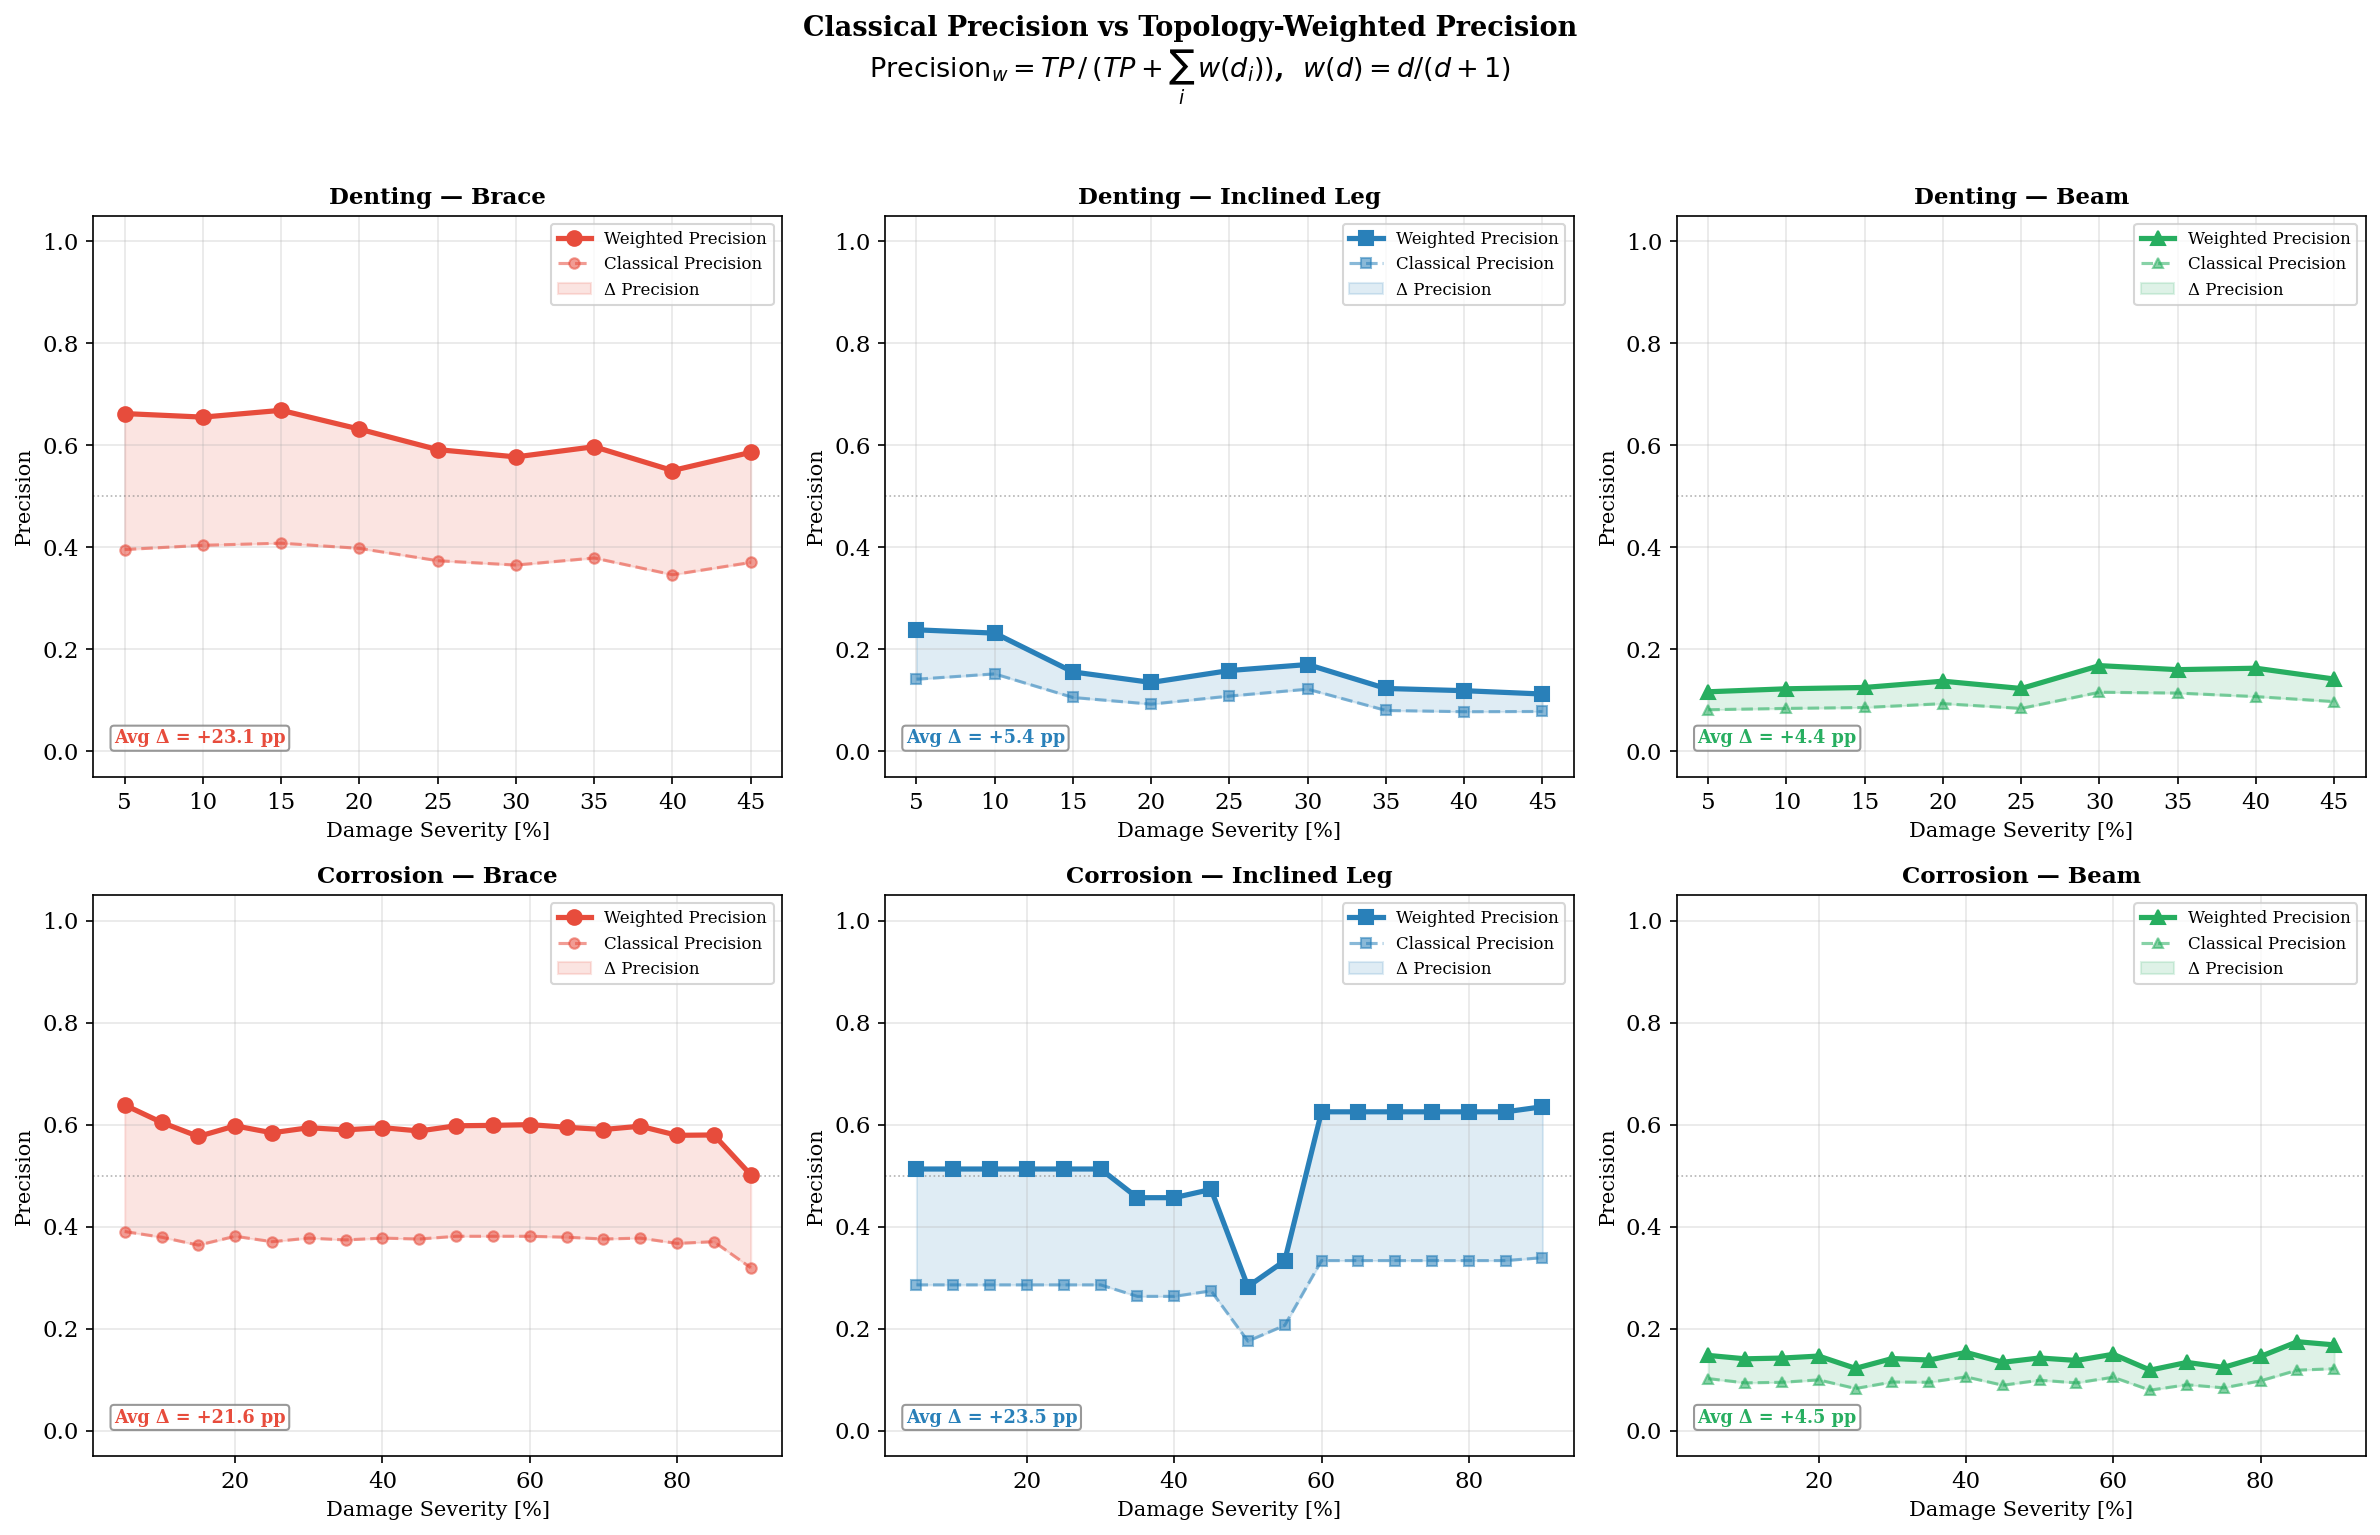

✓ Guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/Precision_clasica_vs_ponderada_por_elemento.png


In [15]:
elem_types = ['Brace', 'Inclined_leg', 'Beam']
dmg_types  = ['Denting', 'Corrosion']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)
fig.suptitle(
    'Classical Precision vs Topology-Weighted Precision\n'
    r'$\mathrm{Precision}_w = TP\,/\,(TP + \sum_i\, w(d_i))$,  '
    r'$w(d) = d/(d+1)$',
    fontsize=13, fontweight='bold', y=1.02
)

for row_idx, damage_type in enumerate(dmg_types):
    tabla = tablas_agg[damage_type]

    for col_idx, mtype in enumerate(elem_types):
        ax = axes[row_idx, col_idx]
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == mtype].sort_values('Porcentaje')
        if sub.empty:
            ax.set_visible(False)
            continue

        color  = ELEM_COLORS.get(mtype, 'gray')
        marker = ELEM_MARKERS.get(mtype, 'o')

        # Precision ponderada
        ax.plot(sub['Porcentaje'], sub['Precision_ponderada_macro'],
                f'{marker}-', color=color, linewidth=2.5, markersize=7,
                label='Weighted Precision', zorder=3)

        # Precision clásica
        ax.plot(sub['Porcentaje'], sub['Precision_clasica_macro'],
                f'{marker}--', color=color, linewidth=1.5, markersize=5,
                alpha=0.55, label='Classical Precision', zorder=2)

        # Relleno diferencial
        ax.fill_between(
            sub['Porcentaje'],
            sub['Precision_clasica_macro'],
            sub['Precision_ponderada_macro'],
            alpha=0.15, color=color,
            label='Δ Precision'
        )

        ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('Damage Severity [%]', fontsize=10)
        ax.set_ylabel('Precision', fontsize=10)
        ax.set_title(f'{damage_type} — {ELEM_LABELS.get(mtype, mtype)}',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3)

        # Anotar delta promedio
        delta_avg = sub['Delta_Precision_pct'].mean()
        ax.text(0.03, 0.06,
                f'Avg Δ = {delta_avg:+.1f} pp',
                transform=ax.transAxes, fontsize=8.5, color=color,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.8, edgecolor='gray'))

plt.tight_layout()
out_fig1 = resultados_nuevos / 'Precision_clasica_vs_ponderada_por_elemento.png'
plt.savefig(out_fig1, dpi=300)
plt.show()
print(f'✓ Guardada: {out_fig1}')

## 9. Figura 2 — Delta Precision (Ponderada − Clásica) por Severidad

Cuantifica cuánto mejora la Precision al considerar proximidad topológica.
Un Δ positivo significa que los FP estaban cerca del elemento dañado.

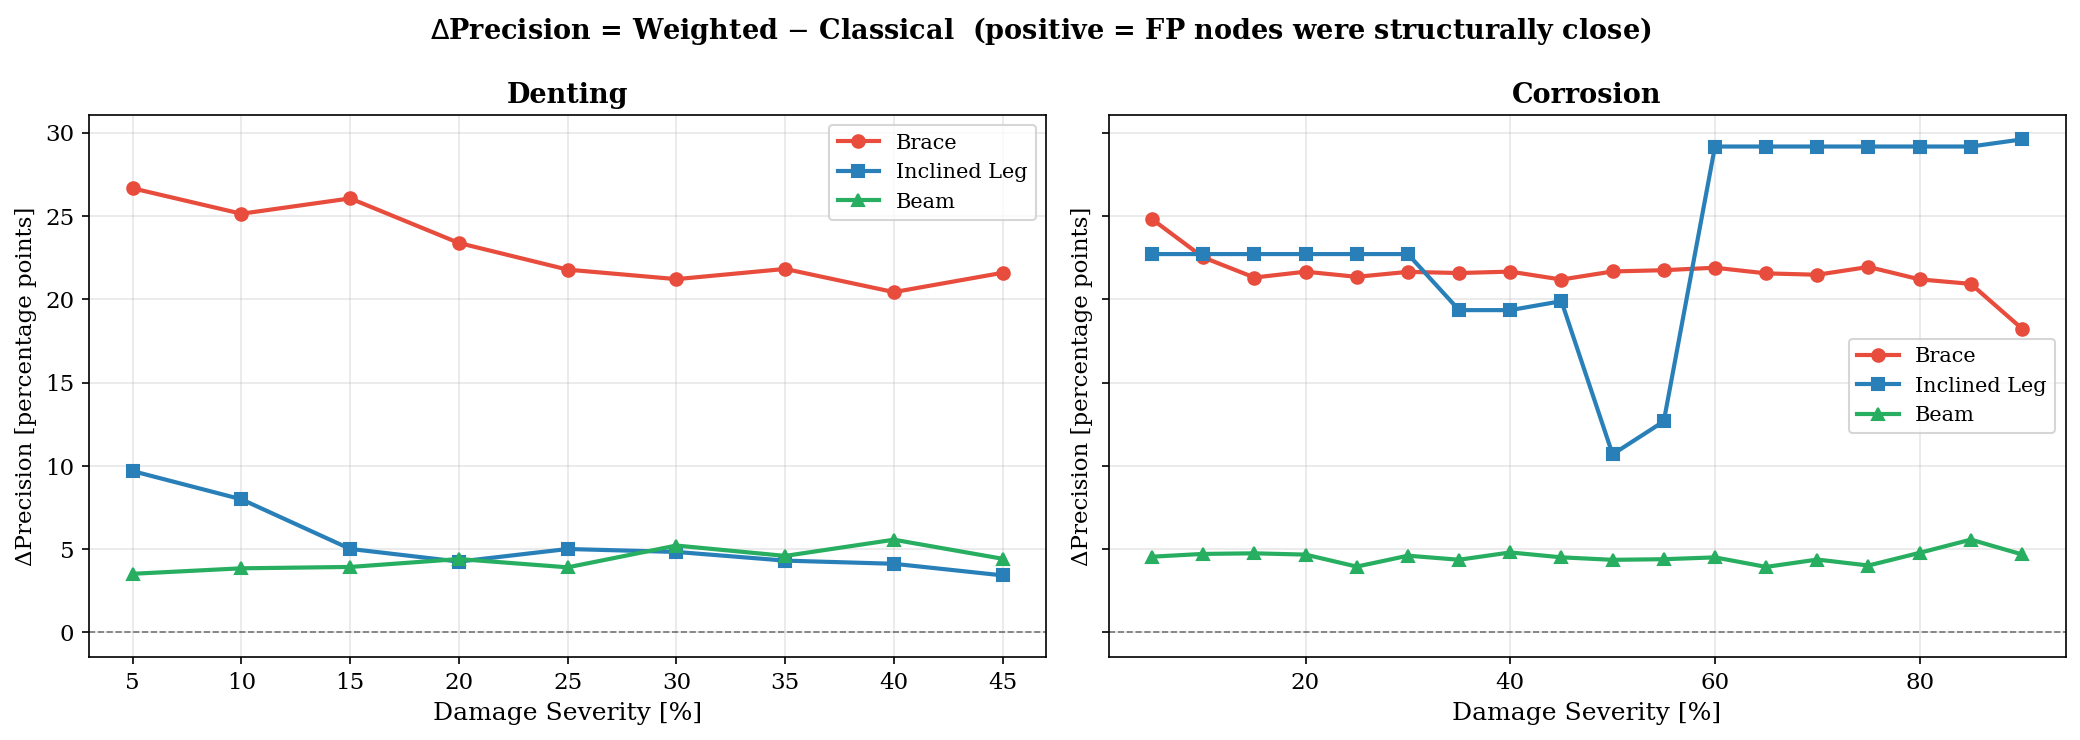

✓ Guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/Delta_Precision_ponderada_vs_clasica.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    r'$\Delta$Precision = Weighted $-$ Classical  (positive = FP nodes were structurally close)',
    fontsize=13, fontweight='bold'
)

for ax, damage_type in zip(axes, dmg_types):
    tabla = tablas_agg[damage_type]
    for mtype in elem_types:
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == mtype].sort_values('Porcentaje')
        if sub.empty:
            continue
        color  = ELEM_COLORS.get(mtype, 'gray')
        marker = ELEM_MARKERS.get(mtype, 'o')
        label  = ELEM_LABELS.get(mtype, mtype)
        ax.plot(sub['Porcentaje'], sub['Delta_Precision_pct'],
                f'{marker}-', color=color, linewidth=2, markersize=6, label=label)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Damage Severity [%]', fontsize=12)
    ax.set_ylabel('ΔPrecision [percentage points]', fontsize=11)
    ax.set_title(damage_type, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_fig2 = resultados_nuevos / 'Delta_Precision_ponderada_vs_clasica.png'
plt.savefig(out_fig2, dpi=300)
plt.show()
print(f'✓ Guardada: {out_fig2}')

## 10. Figura 3 — Distribución de Distancias Topológicas de los FP

¿A qué distancia estructural se encuentran típicamente los nodos FP?  
Esta figura justifica por qué la corrección es necesaria (y cuantifica su impacto).

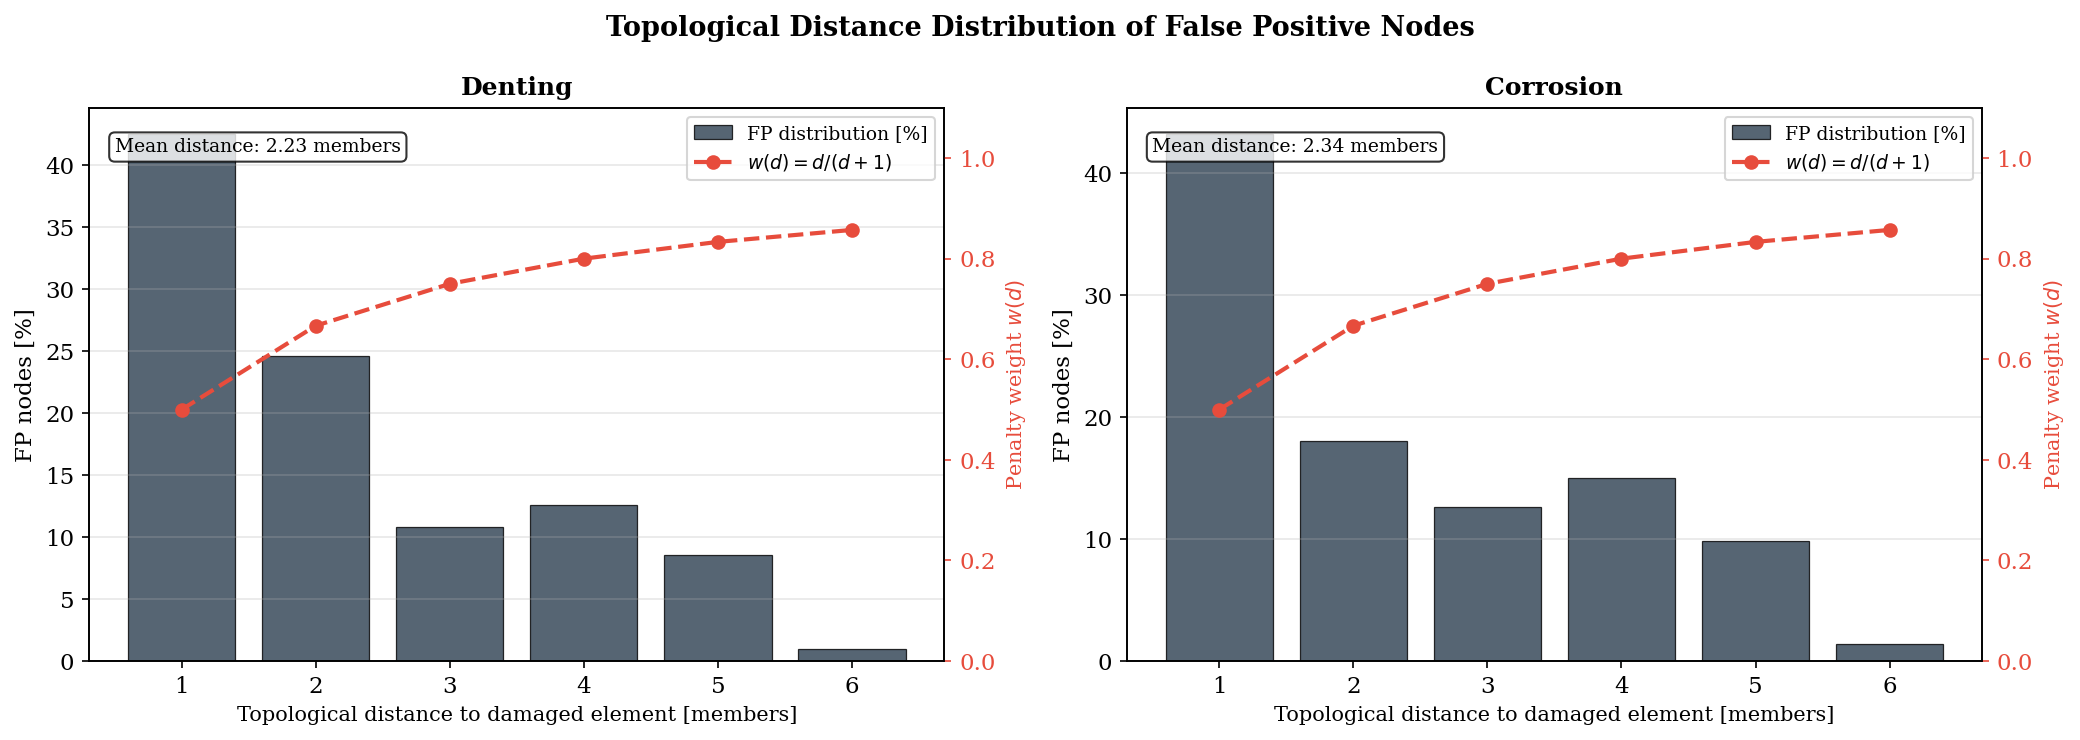

✓ Guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/FP_distancia_topologica_distribucion.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Topological Distance Distribution of False Positive Nodes',
             fontsize=13, fontweight='bold')

for ax, (damage_type, df_pond) in zip(axes, dfs_ponderados.items()):
    all_fp_dists = []
    for _, row in df_pond.iterrows():
        run_id   = int(row['ID'])
        elem_id  = int(row['Elemento'])
        fp_nodes = fp_by_type[damage_type].get(run_id, [])
        true_nodes = set(filter(None, elem_to_nodes.get(elem_id, (None, None))))
        for fp in fp_nodes:
            d = fp_distance_to_element(fp, true_nodes, all_distances)
            if d < 999:  # ignorar desconectados
                all_fp_dists.append(d)

    if not all_fp_dists:
        ax.set_title(f'{damage_type} — sin datos')
        continue

    all_fp_dists = np.array(all_fp_dists)
    unique, counts = np.unique(all_fp_dists, return_counts=True)
    pct = counts / counts.sum() * 100
    weights = weight_fn(unique)

    bars = ax.bar(unique, pct, color='#2C3E50', alpha=0.8, edgecolor='black',
                  linewidth=0.6, label='FP distribution [%]')

    # Superponer w(d) como línea
    ax2 = ax.twinx()
    ax2.plot(unique, weights, 'o--', color='#E74C3C', linewidth=2, markersize=6,
             label=r'$w(d) = d/(d+1)$')
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel(r'Penalty weight $w(d)$', fontsize=10, color='#E74C3C')
    ax2.tick_params(axis='y', colors='#E74C3C')

    ax.set_xlabel('Topological distance to damaged element [members]', fontsize=10)
    ax.set_ylabel('FP nodes [%]', fontsize=11)
    ax.set_title(damage_type, fontsize=12, fontweight='bold')
    ax.set_xticks(unique)
    ax.grid(axis='y', alpha=0.3)

    # Leyendas combinadas
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')

    d_media = all_fp_dists.mean()
    ax.text(0.03, 0.92, f'Mean distance: {d_media:.2f} members',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
out_fig3 = resultados_nuevos / 'FP_distancia_topologica_distribucion.png'
plt.savefig(out_fig3, dpi=300)
plt.show()
print(f'✓ Guardada: {out_fig3}')

## 11. Figura 4 — Comparación Global: Precision Clásica vs Ponderada (barras agrupadas)

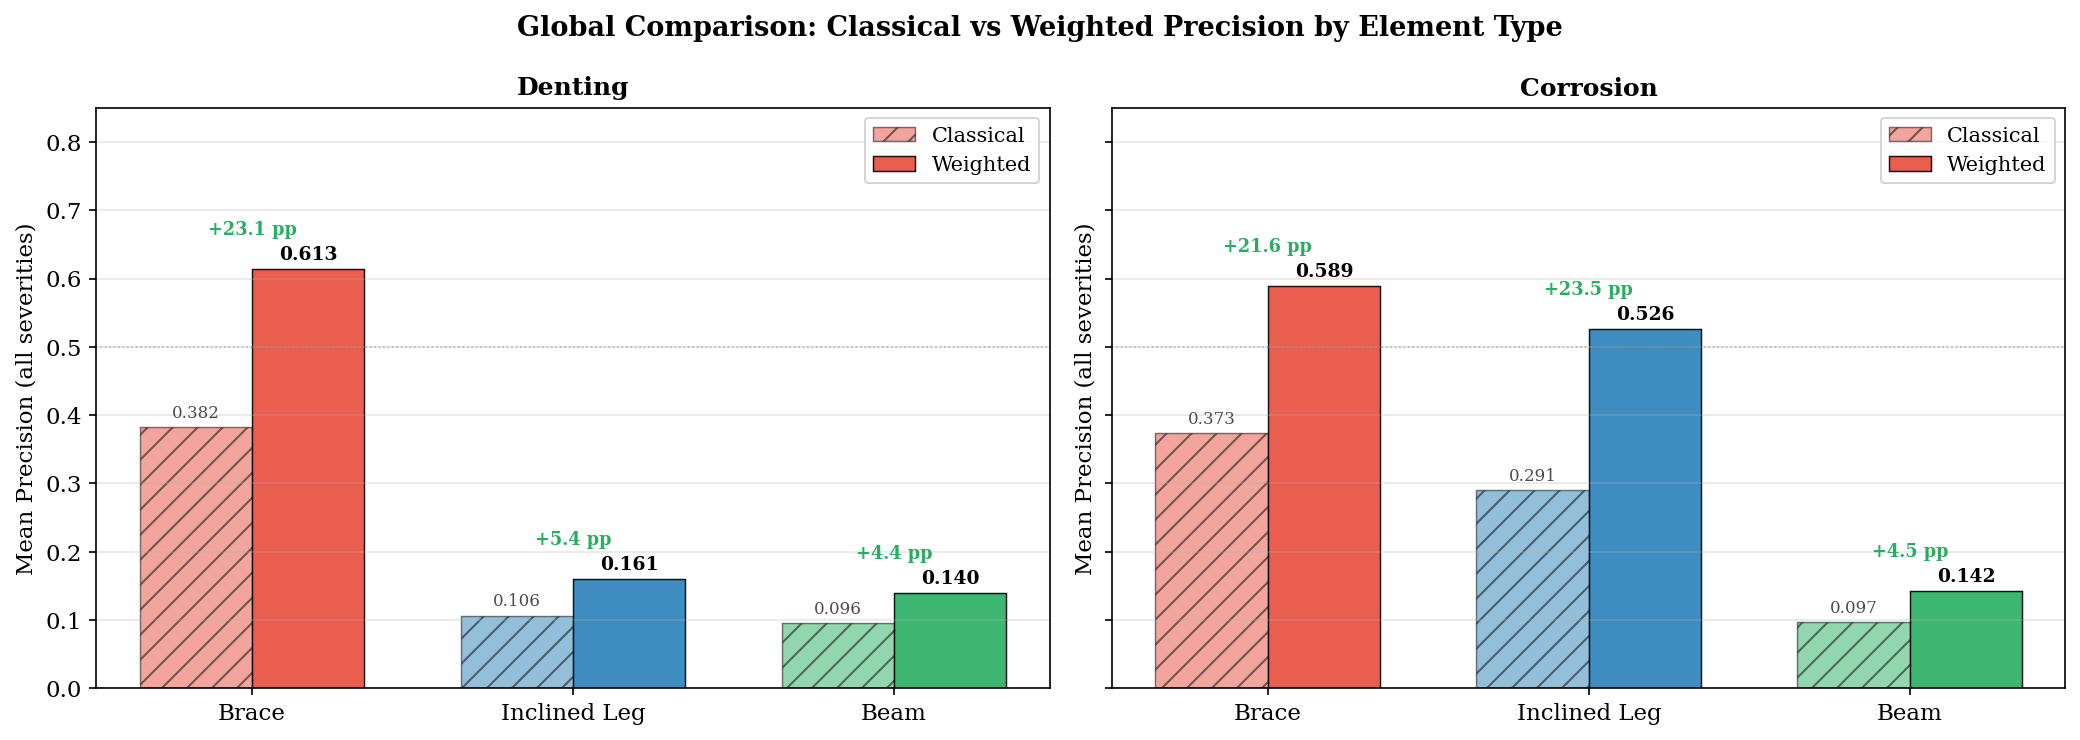

✓ Guardada: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/Precision_global_clasica_vs_ponderada.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Global Comparison: Classical vs Weighted Precision by Element Type',
             fontsize=13, fontweight='bold')

for ax, damage_type in zip(axes, dmg_types):
    tabla = tablas_agg[damage_type]

    # Media global por tipo de elemento
    resumen = tabla.groupby('Tipo_elemento_a_buscar').agg(
        Prec_clasica   =('Precision_clasica_macro', 'mean'),
        Prec_ponderada =('Precision_ponderada_macro', 'mean'),
    ).reset_index()

    mtypes = ['Brace', 'Inclined_leg', 'Beam']
    resumen = resumen.set_index('Tipo_elemento_a_buscar').reindex(mtypes).reset_index()

    x  = np.arange(len(mtypes))
    w  = 0.35
    colors_bar = [ELEM_COLORS.get(m, 'gray') for m in mtypes]

    bars_c = ax.bar(x - w/2, resumen['Prec_clasica'], w,
                    color=colors_bar, alpha=0.50, edgecolor='black',
                    linewidth=0.7, label='Classical', hatch='//')
    bars_w = ax.bar(x + w/2, resumen['Prec_ponderada'], w,
                    color=colors_bar, alpha=0.90, edgecolor='black',
                    linewidth=0.7, label='Weighted')

    for bar, val in zip(bars_c, resumen['Prec_clasica']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, alpha=0.7)
    for bar, val in zip(bars_w, resumen['Prec_ponderada']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Anotación delta
    for i, (vc, vw) in enumerate(zip(resumen['Prec_clasica'], resumen['Prec_ponderada'])):
        delta_pp = (vw - vc) * 100
        ymax = max(vc, vw) + 0.05
        ax.annotate(f'{delta_pp:+.1f} pp', xy=(i, ymax), ha='center', fontsize=8.5,
                    color='#27AE60' if delta_pp >= 0 else '#E74C3C', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([ELEM_LABELS.get(m, m) for m in mtypes], fontsize=11)
    ax.set_ylim(0, 0.85)
    ax.set_ylabel('Mean Precision (all severities)', fontsize=11)
    ax.set_title(damage_type, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

plt.tight_layout()
out_fig4 = resultados_nuevos / 'Precision_global_clasica_vs_ponderada.png'
plt.savefig(out_fig4, dpi=300)
plt.show()
print(f'✓ Guardada: {out_fig4}')

## 12. Exportar Tabla LaTeX para `main.tex`

In [19]:
latex_rows = []
for damage_type in ['Denting', 'Corrosion']:
    tabla = tablas_agg[damage_type]
    for mtype in ['Brace', 'Inclined_leg', 'Beam']:
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == mtype].sort_values('Porcentaje')
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            latex_rows.append({
                'Damage Type':       damage_type,
                'Element':           ELEM_LABELS.get(mtype, mtype),
                'Severity [\\%]':    int(row['Porcentaje']),
                'Prec. Classical':   f"{row['Precision_clasica_macro']:.3f}",
                'Prec. Weighted':    f"{row['Precision_ponderada_macro']:.3f}",
                '$\\Delta$ [pp]':    f"{row['Delta_Precision_pct']:+.1f}",
                'Avg FP dist [mbr]': f"{row['dist_media_FP']:.2f}" if not pd.isna(row['dist_media_FP']) else '--',
            })

df_latex = pd.DataFrame(latex_rows)

# Generar LaTeX
n_cols  = len(df_latex.columns)
col_fmt = 'l' * 2 + 'r' * (n_cols - 2)
lines   = []
lines.append(r'\begin{table}[htbp]')
lines.append(r'  \centering')
lines.append(r'  \caption{Comparison of Classical and Topology-Weighted Precision. '
             r'$\Delta$ = Weighted $-$ Classical (percentage points). '
             r'Avg FP dist: mean topological distance (in structural members) '
             r'between false-positive nodes and the damaged element. '
             r'Weight function: $w(d)=d/(d+1)$.}')
lines.append(r'  \label{tab:precision_ponderada}')
lines.append(r'  \small')
lines.append(r'  \begin{tabular}{' + col_fmt + r'}')
lines.append(r'    \toprule')
lines.append('    ' + ' & '.join(df_latex.columns) + r' \\')
lines.append(r'    \midrule')

prev_dmg  = None
prev_elem = None
for _, row in df_latex.iterrows():
    cur_dmg  = row['Damage Type']
    cur_elem = row['Element']
    if prev_dmg is not None and cur_dmg != prev_dmg:
        lines.append(r'    \midrule')
    elif prev_elem is not None and cur_elem != prev_elem and cur_dmg == prev_dmg:
        lines.append(r'    \cmidrule{2-' + str(n_cols) + r'}')
    lines.append('    ' + ' & '.join(str(v) for v in row.values) + r' \\')
    prev_dmg  = cur_dmg
    prev_elem = cur_elem

lines.append(r'    \bottomrule')
lines.append(r'  \end{tabular}')
lines.append(r'\end{table}')
latex_str = '\n'.join(lines)

out_tex = tablas_dir / 'tabla_precision_ponderada.tex'
out_tex.write_text(latex_str, encoding='utf-8')
print(f'✓ Tabla LaTeX guardada: {out_tex}')
print()
print(latex_str[:1200])

✓ Tabla LaTeX guardada: /home/fcisnerosr/github/Proyecto-doctoral/manuscript_AOR/tablas/tabla_precision_ponderada.tex

\begin{table}[htbp]
  \centering
  \caption{Comparison of Classical and Topology-Weighted Precision. $\Delta$ = Weighted $-$ Classical (percentage points). Avg FP dist: mean topological distance (in structural members) between false-positive nodes and the damaged element. Weight function: $w(d)=d/(d+1)$.}
  \label{tab:precision_ponderada}
  \small
  \begin{tabular}{llrrrrr}
    \toprule
    Damage Type & Element & Severity [\%] & Prec. Classical & Prec. Weighted & $\Delta$ [pp] & Avg FP dist [mbr] \\
    \midrule
    Denting & Brace & 5 & 0.396 & 0.662 & +26.7 & 2.20 \\
    Denting & Brace & 10 & 0.404 & 0.655 & +25.1 & 2.16 \\
    Denting & Brace & 15 & 0.408 & 0.669 & +26.1 & 2.07 \\
    Denting & Brace & 20 & 0.398 & 0.632 & +23.4 & 4.40 \\
    Denting & Brace & 25 & 0.374 & 0.592 & +21.8 & 4.09 \\
    Denting & Brace & 30 & 0.365 & 0.577 & +21.2 & 4.01 \\
    Denti

## 13. Resumen Final

In [20]:
print('=' * 65)
print('RESUMEN — PRECISION PONDERADA POR DISTANCIA TOPOLÓGICA')
print('=' * 65)
print()
print('Función de peso: w(d) = d/(d+1)')
print('  d=1 (adyacente)  → w=0.50  (penaliza 50%)')
print('  d=2              → w=0.67')
print('  d=3              → w=0.75')
print('  d→∞              → w→1.00  (penalización completa)')
print()

for damage_type in dmg_types:
    tabla = tablas_agg[damage_type]
    print(f'{damage_type}:')
    for mtype in ['Brace', 'Inclined_leg', 'Beam']:
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == mtype]
        if sub.empty:
            continue
        pc_mean = sub['Precision_clasica_macro'].mean()
        pw_mean = sub['Precision_ponderada_macro'].mean()
        delta   = (pw_mean - pc_mean) * 100
        d_mean  = sub['dist_media_FP'].mean()
        label   = ELEM_LABELS.get(mtype, mtype)
        print(f'  {label:14s}: clásica={pc_mean:.3f}  ponderada={pw_mean:.3f}  '
              f'Δ={delta:+.1f} pp  (d_FP_media={d_mean:.2f})')
    print()

print('Archivos generados:')
print('  Precision_clasica_vs_ponderada_por_elemento.png')
print('  Delta_Precision_ponderada_vs_clasica.png')
print('  FP_distancia_topologica_distribucion.png')
print('  Precision_global_clasica_vs_ponderada.png')
print('  manuscript_AOR/tablas/tabla_precision_ponderada.tex')
print()
print('✅ NB10 COMPLETADO')

RESUMEN — PRECISION PONDERADA POR DISTANCIA TOPOLÓGICA

Función de peso: w(d) = d/(d+1)
  d=1 (adyacente)  → w=0.50  (penaliza 50%)
  d=2              → w=0.67
  d=3              → w=0.75
  d→∞              → w→1.00  (penalización completa)

Denting:
  Brace         : clásica=0.382  ponderada=0.613  Δ=+23.1 pp  (d_FP_media=3.43)
  Inclined Leg  : clásica=0.106  ponderada=0.161  Δ=+5.4 pp  (d_FP_media=1.65)
  Beam          : clásica=0.096  ponderada=0.140  Δ=+4.4 pp  (d_FP_media=1.54)

Corrosion:
  Brace         : clásica=0.373  ponderada=0.589  Δ=+21.6 pp  (d_FP_media=3.40)
  Inclined Leg  : clásica=0.291  ponderada=0.526  Δ=+23.5 pp  (d_FP_media=1.22)
  Beam          : clásica=0.097  ponderada=0.142  Δ=+4.5 pp  (d_FP_media=1.42)

Archivos generados:
  Precision_clasica_vs_ponderada_por_elemento.png
  Delta_Precision_ponderada_vs_clasica.png
  FP_distancia_topologica_distribucion.png
  Precision_global_clasica_vs_ponderada.png
  manuscript_AOR/tablas/tabla_precision_ponderada.tex

✅ NB